In [1]:
%matplotlib inline
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os

csv_path = 'matches.csv'
if not os.path.exists(csv_path):
    print("matches.csv nahi mili! Synthetic data use kar rahe hain...")
    teams = ['MI','CSK','RCB','KKR','DC','SRH','PBKS','RR']
    np.random.seed(42)
    n = 800
    df = pd.DataFrame({
        'season':   np.random.randint(2008, 2021, n),
        'winner':   np.random.choice(teams, n,
                        p=[.18,.17,.12,.12,.11,.11,.10,.09]),
        'city':     np.random.choice(
                        ['Mumbai','Chennai','Kolkata','Delhi',
                         'Bangalore','Hyderabad','Jaipur'], n),
        'win_by_runs':   np.random.randint(0, 100, n),
        'win_by_wickets': np.random.randint(0, 10, n),
        'player_of_match': np.random.choice(
                        ['Kohli','Rohit','Dhoni','Warner','Gayle'], n),
        'toss_decision': np.random.choice(['bat','field'], n),
    })
else:
    df = pd.read_csv(csv_path)  # Real Kaggle file padhna

print("="*52)
print("  PROGRAM 1 — IPL BASIC ANALYSIS")
print("="*52)
print(f"\nDataset shape    : {df.shape}")
print(f"Total columns    : {df.shape[1]}")
print(f"Missing values   :\n{df.isnull().sum()[df.isnull().sum() > 0]}")

  PROGRAM 1 — IPL BASIC ANALYSIS

Dataset shape    : (1095, 20)
Total columns    : 20
Missing values   :
city                 51
player_of_match       5
winner                5
result_margin        19
target_runs           3
target_overs          3
method             1074
dtype: int64


In [2]:
if 'city' in df.columns:
    df['city'].fillna('Unknown', inplace=True)
if 'winner' in df.columns:
    df.dropna(subset=['winner'], inplace=True)
df.reset_index(drop=True, inplace=True)
print(f"\nCleaned shape    : {df.shape}")


Cleaned shape    : (1090, 20)


In [3]:
wins = df['winner'].value_counts()
top5_teams = wins.head(5)

print(f"\nTop 5 IPL Winners:")
print(top5_teams.to_string())

if 'win_by_runs' in df.columns:
    runs_arr = df['win_by_runs'].dropna().values  # NumPy array
    print(f"\nWin by runs stats (NumPy):")
    print(f"  Mean   : {np.mean(runs_arr):.2f}")
    print(f"  Max    : {np.max(runs_arr)}")
    print(f"  Std    : {np.std(runs_arr):.2f}")


Top 5 IPL Winners:
winner
Mumbai Indians                 144
Chennai Super Kings            138
Kolkata Knight Riders          131
Royal Challengers Bangalore    116
Rajasthan Royals               112



Chart saved: ipl_chart1.png


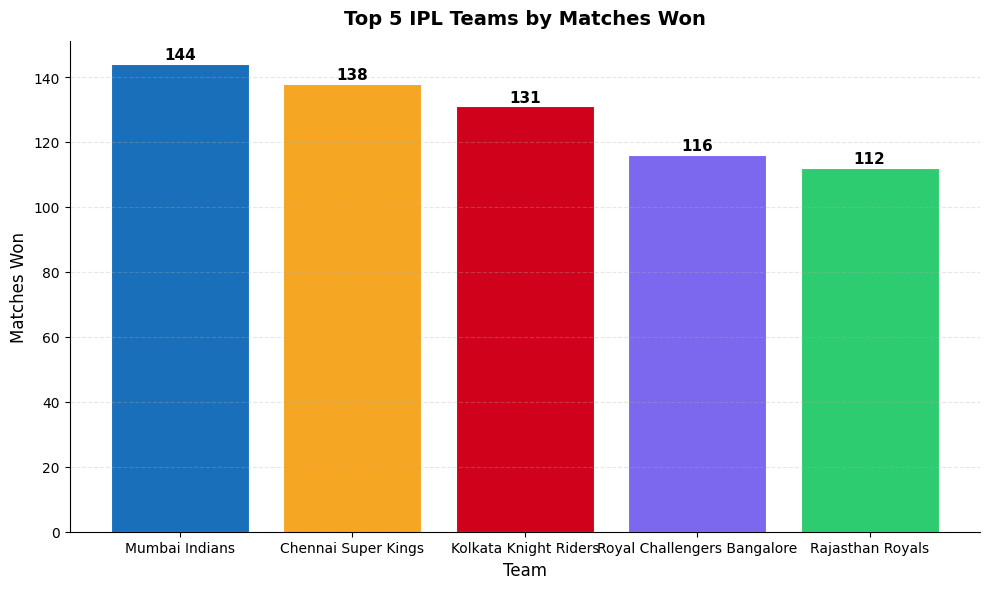

In [4]:
fig, ax = plt.subplots(figsize=(10, 6))

colors = ['#1a6fba','#f5a623','#d0021b','#7b68ee','#2ecc71']
bars = ax.bar(top5_teams.index, top5_teams.values,
              color=colors, edgecolor='white', linewidth=0.8)

# Har bar ke upar value dikhao
for bar in bars:
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height() + 0.5,
            str(int(bar.get_height())),
            ha='center', va='bottom', fontsize=11, fontweight='bold')

ax.set_title('Top 5 IPL Teams by Matches Won', fontsize=14, fontweight='bold', pad=12)
ax.set_xlabel('Team', fontsize=12)
ax.set_ylabel('Matches Won', fontsize=12)
ax.grid(axis='y', alpha=0.3, linestyle='--')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()

# Image save karo — same folder mein PNG file ban jaegi
plt.savefig('ipl_chart1.png', dpi=150, bbox_inches='tight')
print("\nChart saved: ipl_chart1.png")
plt.show()

In [6]:
df.to_excel('ipl_cleaned.xlsx', index=False)
print("Excel saved: ipl_cleaned.xlsx")
print("\n[Program 1 Complete]")

Excel saved: ipl_cleaned.xlsx

[Program 1 Complete]
